# Módulo 1 — MLPs y Backpropagation
## Laboratorio: serie de producción de Alcalá (UPRA-EVA 2019-2025)

**Objetivos**
1. Forward pass y backpropagation desde cero (NumPy puro).
2. Verificación numérica de gradientes (finite differences).
3. Comparación justa MLP vs baseline oficial (Promedio Móvil 3A, MAPE 4.2%).

**Modelo matemático**
- Forward: $z_l = W_l a_{l-1} + b_l$, $\quad a_l = \sigma_l(z_l)$
- Loss: $L = \frac{1}{N}\sum (\hat y - y)^2$
- Backward: $\delta_L = \partial L/\partial z_L$, $\quad \delta_l = (W_{l+1}^T \delta_{l+1}) \odot \sigma_l'(z_l)$
- Update: $W_l \leftarrow W_l - \eta\, \delta_l a_{l-1}^T$

**Guardado:** entradas en `core/ml/data/`, resultados en `core/ml/results/`.

In [1]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "app.py").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from core.ml.mlp_scratch import MLP, gradient_check, mape, mse_loss
from core.ml.io_utils import save_json, save_csv, RESULTS, DATA
print("raiz:", ROOT)
print("resultados ->", RESULTS)

raiz: C:\Users\Usuario\Documentos\eva-valle-v3.0
resultados -> C:\Users\Usuario\Documentos\eva-valle-v3.0\core\ml\results


## 1.1 Funciones de activación y sus derivadas

| Función | $\sigma(z)$ | $\sigma'(z)$ | Uso |
|---|---|---|---|
| Sigmoide | $1/(1+e^{-z})$ | $\sigma(1-\sigma)$ | salida binaria |
| Tanh | $\tanh(z)$ | $1-\tanh^2$ | capas ocultas pequeñas |
| ReLU | $\max(0,z)$ | $1_{z>0}$ | default ocultas |
| Lineal | $z$ | $1$ | salida en regresión |

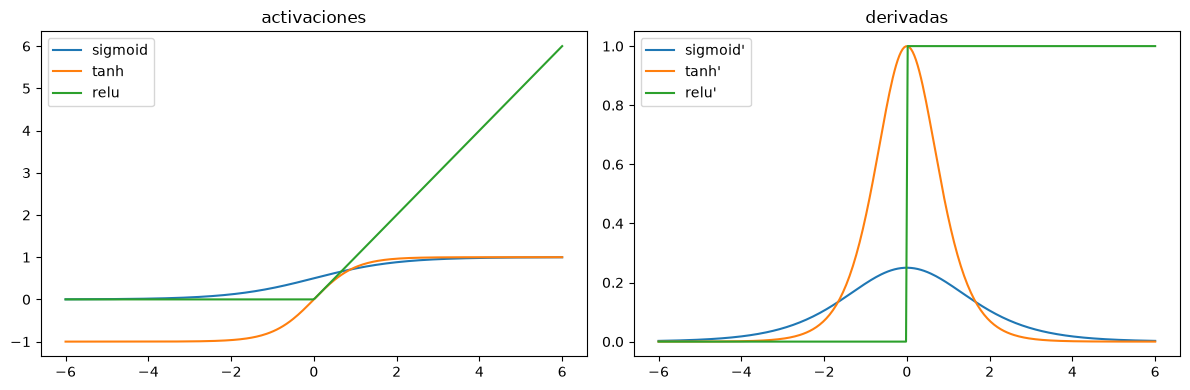

In [2]:
import matplotlib.pyplot as plt
z = np.linspace(-6, 6, 300)
acts = {"sigmoid": (1/(1+np.exp(-z))), "tanh": np.tanh(z), "relu": np.maximum(0, z)}
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for k, v in acts.items():
    ax[0].plot(z, v, label=k)
ax[0].legend(); ax[0].set_title("activaciones")
ax[1].plot(z, 1/(1+np.exp(-z))*(1-1/(1+np.exp(-z))), label="sigmoid'")
ax[1].plot(z, 1-np.tanh(z)**2, label="tanh'")
ax[1].plot(z, (z > 0).astype(float), label="relu'")
ax[1].legend(); ax[1].set_title("derivadas")
plt.tight_layout(); plt.show()

## 1.2 Verificación 1 — XOR (no linealmente separable)
Un perceptrón simple **no puede** resolver XOR; un MLP de 2 capas sí.

MLP: [2, 4, 1]
Capa 1: 2 -> 4 | tanh     | params: 12
Capa 2: 4 -> 1 | sigmoid  | params: 5
Total parametros: 17
Epoch  1000 | Loss: 0.002381 | MAPE: 4.40%
Epoch  2000 | Loss: 0.000815 | MAPE: 2.54%
Epoch  3000 | Loss: 0.000479 | MAPE: 1.94%
Epoch  4000 | Loss: 0.000336 | MAPE: 1.62%
Epoch  5000 | Loss: 0.000258 | MAPE: 1.41%
pred: [0.017 0.982 0.99  0.018] | esperado: [0 1 1 0]
[OK] guardado: C:\Users\Usuario\Documentos\eva-valle-v3.0\core\ml\results\m1_xor_metrics.json


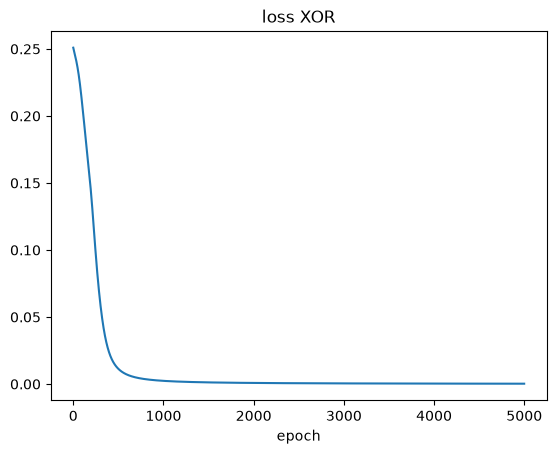

In [3]:
X = np.array([[0, 0, 1, 1], [0, 1, 0, 1]])
y = np.array([[0, 1, 1, 0]])
net = MLP([2, 4, 1], ["tanh", "sigmoid"], seed=42)
print(net.summary())
h = net.fit(X, y, epochs=5000, lr=0.5, verbose=1000)
pred = net.predict(X).round(3).flatten()
print("pred:", pred, "| esperado: [0 1 1 0]")
save_json("m1_xor_metrics.json", {"loss_final": h["loss"][-1],
          "pred": pred.tolist(), "esperado": [0, 1, 1, 0]})
plt.plot(h["loss"]); plt.title("loss XOR"); plt.xlabel("epoch"); plt.show()

In [4]:
net2 = MLP([3, 5, 2], ["relu", "linear"], seed=7)
Xt, yt = np.random.randn(3, 10), np.random.randn(2, 10)
err = gradient_check(net2, Xt, yt)
save_json("m1_gradient_check.json", {"error_relativo": err, "umbral_ok": 1e-5})

Gradient Check — Error relativo: 6.06e-09
✅ Backpropagation correcto
[OK] guardado: C:\Users\Usuario\Documentos\eva-valle-v3.0\core\ml\results\m1_gradient_check.json


WindowsPath('C:/Users/Usuario/Documentos/eva-valle-v3.0/core/ml/results/m1_gradient_check.json')

## 1.3 Datos reales — Alcalá (verificación contra el PDF firmado)

| Año | Prod (t) | Área (ha) | Rend (t/ha) |
|---|---|---|---|
| 2019 | 32,556 | 3,327 | 10.90 |
| 2020 | 39,579 | 3,683 | 12.82 |
| 2021 | 47,312 | 3,669 | 14.54 |
| 2022 | 38,978 | 3,456 | 12.08 |
| 2023 | 37,114 | 3,403 | 12.35 |
| 2024 | 38,594 | 3,558 | 12.74 |
| 2025 | 41,878 | 3,677 | 13.41 |

In [5]:
from config.settings import settings
df = pd.read_csv(settings.DATA_MODEL_PATH / "eva_agricola_valle_modelo_conceptual.csv",
                 low_memory=False)
alc = df[df.municipio == "Alcalá"].groupby("ano")[["produccion_t", "area_cosechada_ha"]].sum().reset_index()
PDF = {2019: 32556, 2020: 39579, 2021: 47312, 2022: 38978,
       2023: 37114, 2024: 38594, 2025: 41878}
alc["pdf"] = alc.ano.map(PDF)
alc["diff_pct"] = ((alc.produccion_t - alc.pdf) / alc.pdf * 100).round(2)
print(alc.to_string(index=False))
assert (alc.diff_pct.abs() < 1).all(), "discrepancia con el PDF firmado"
print("[OK] serie verificada contra el PDF firmado")

 ano  produccion_t  area_cosechada_ha   pdf  diff_pct
2019      32556.25            2986.00 32556       0.0
2020      39578.71            3087.09 39579      -0.0
2021      47312.13            3253.59 47312       0.0
2022      38977.90            3227.96 38978      -0.0
2023      37114.20            3005.64 37114       0.0
2024      38594.24            3028.56 38594       0.0
2025      41878.19            3123.60 41878       0.0
[OK] serie verificada contra el PDF firmado


In [6]:
DATA.mkdir(parents=True, exist_ok=True)
alc["rend"] = alc.produccion_t / alc.area_cosechada_ha
rows = []
for i in range(2, len(alc)):
    rows.append({"ano": alc.ano.iloc[i], "prod": alc.produccion_t.iloc[i],
                 "area": alc.area_cosechada_ha.iloc[i], "rend": alc.rend.iloc[i],
                 "prod_t1": alc.produccion_t.iloc[i-1], "prod_t2": alc.produccion_t.iloc[i-2]})
F = pd.DataFrame(rows)
print(F.to_string(index=False))

feats = ["ano", "area", "rend", "prod_t1", "prod_t2"]
Xr, yr = F[feats].values, F[["prod"]].values
X_min, X_max = Xr.min(0), Xr.max(0)
y_min, y_max = yr.min(), yr.max()
Xn = (Xr - X_min) / (X_max - X_min + 1e-8)
yn = (yr - y_min) / (y_max - y_min + 1e-8)
np.save(DATA / "X_alcala.npy", Xn); np.save(DATA / "y_alcala.npy", yn)
np.save(DATA / "anos_alcala.npy", F.ano.values)
print("[OK] features normalizadas guardadas en", DATA)

 ano     prod    area      rend  prod_t1  prod_t2
2021 47312.13 3253.59 14.541516 39578.71 32556.25
2022 38977.90 3227.96 12.075088 47312.13 39578.71
2023 37114.20 3005.64 12.348185 38977.90 47312.13
2024 38594.24 3028.56 12.743429 37114.20 38977.90
2025 41878.19 3123.60 13.407027 38594.24 37114.20
[OK] features normalizadas guardadas en C:\Users\Usuario\Documentos\eva-valle-v3.0\core\ml\data


## 1.4 Protocolo de comparación justa (folds 2022-2025)

- **MLP:** entrena con los años restantes del bloque 2021-2025 (leave-one-out).
- **Baseline oficial:** Promedio Móvil 3A (el modelo ganador del PDF, MAPE 4.2%).
- Métrica: MAPE por fold y MAPE promedio. El que tenga **menor MAPE promedio** gana.

In [7]:
anos = F.ano.values
folds = [2022, 2023, 2024, 2025]
res = []
pesos_ult = None
for f in folds:
    tr = [i for i, a in enumerate(anos) if a != f and a >= 2021]
    te = [i for i, a in enumerate(anos) if a == f][0]
    m = MLP([5, 8, 4, 1], ["relu", "relu", "linear"], seed=42)
    m.fit(Xn[tr].T, yn[tr].T, epochs=4000, lr=0.05, verbose=0)
    p_n = m.predict(Xn[[te]].T).flatten()[0]
    p_mlp = p_n * (y_max - y_min) + y_min
    i = te
    p_pm3 = F["prod"].iloc[[i-1, i-2, i-3]].mean()  # ← CORREGIDO
    real = F["prod"].iloc[i]                          # ← CORREGIDO
    res.append({"ano": int(f), "real_t": real, "mlp_t": round(p_mlp, 0),
                "pm3a_t": round(p_pm3, 0),
                "mape_mlp": round(abs(p_mlp - real) / real * 100, 2),
                "mape_pm3a": round(abs(p_pm3 - real) / real * 100, 2)})
    pesos_ult = [W.tolist() for W in m.W]
R = pd.DataFrame(res)
R.loc["PROM", ["mape_mlp", "mape_pm3a"]] = R[["mape_mlp", "mape_pm3a"]].mean().round(2)
print(R.to_string(index=False))
save_csv("m1_alcala_predicciones.csv", R)
save_json("m1_alcala_metrics.json", {"mape_mlp_prom": float(R.mape_mlp.mean()),
          "mape_pm3a_prom": float(R.mape_pm3a.mean()),
          "gana": "MLP" if R.mape_mlp.mean() < R.mape_pm3a.mean() else "PM3A"})
save_json("m1_alcala_pesos.json", {"W": pesos_ult})

   ano   real_t   mlp_t  pm3a_t  mape_mlp  mape_pm3a
2022.0 38977.90 42647.0 42595.0      9.41       9.28
2023.0 37114.20 36808.0 42723.0      0.83      15.11
2024.0 38594.24 38523.0 41135.0      0.18       6.58
2025.0 41878.19 41514.0 38229.0      0.87       8.71
   NaN      NaN     NaN     NaN      2.82       9.92
[OK] guardado: C:\Users\Usuario\Documentos\eva-valle-v3.0\core\ml\results\m1_alcala_predicciones.csv
[OK] guardado: C:\Users\Usuario\Documentos\eva-valle-v3.0\core\ml\results\m1_alcala_metrics.json
[OK] guardado: C:\Users\Usuario\Documentos\eva-valle-v3.0\core\ml\results\m1_alcala_pesos.json


WindowsPath('C:/Users/Usuario/Documentos/eva-valle-v3.0/core/ml/results/m1_alcala_pesos.json')

## 1.5 Interpretación (sesgo-varianza)

Con **n = 5** muestras, un MLP tiene varianza alta: es *esperable* que el baseline
simple gane o empate. Eso **no** es un fracaso del MLP: es la lección central —
la complejidad del modelo debe crecer con el tamaño de la muestra.
El MLP brillará en el Módulo 2 (series largas por cultivo) y Módulo 5 (multi-cultivo).

**Artefactos de este módulo:** revisa `core/ml/results/` —
`m1_xor_metrics.json`, `m1_gradient_check.json`, `m1_alcala_predicciones.csv`,
`m1_alcala_metrics.json`, `m1_alcala_pesos.json`.

---
## ➡️ Módulo 2: RNNs y series temporales (LSTM/GRU)
Se habilita al cerrar el Módulo 1.